#ML1 Examen Aplicado

**Alumno: Rodolfo Cheuquiante D.**

MACHINE LEARNING I | tIIAD1008-01

Profesor: Danilo Alberto Gomez

In [1]:
# ==========================================
# LIBRERÍAS GLOBALES
# ==========================================
import os
import time
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error
from sklearn.metrics import silhouette_score



#Punto 3: Declaración del Dataset
En este proyecto utilizaremos el dataset "Student Career Success Prediction" obtenido desde Kaggle (URL: [https://www.kaggle.com/datasets/mobeenfatimah/student-career-success-prediction-dataset](https://www.kaggle.com/datasets/mobeenfatimah/student-career-success-prediction-dataset)). El conjunto de datos cuenta con 50.000 filas y 29 columnas. La variable objetivo definida para este análisis es Employability_Score, por lo que la tarea a desarrollar corresponde a un problema de Regresión.


#Punto 4: Carga y Exploración Inicial
A continuación, se procede a descargar y cargar el dataset utilizando pandas. Además, se ejecutan los comandos exploratorios básicos (shape, dtypes, info, describe, head) para comprender la estructura y los tipos de datos disponibles.

In [2]:
# Descarga del dataset
path = kagglehub.dataset_download("mobeenfatimah/student-career-success-prediction-dataset")
csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]
file_path = os.path.join(path, csv_files[0]) if csv_files else path

# Carga y exploración
df = pd.read_csv(file_path)
print("=== DIMENSIONES ==="); print(df.shape)
print("\n=== TIPOS DE DATOS ==="); print(df.dtypes)
print("\n=== INFORMACIÓN ==="); df.info()
print("\n=== DESCRIPTIVAS ==="); display(df.describe())
print("\n=== HEAD ==="); display(df.head())


Using Colab cache for faster access to the 'student-career-success-prediction-dataset' dataset.
=== DIMENSIONES ===
(50000, 29)

=== TIPOS DE DATOS ===
Student_ID                object
Age                        int64
Gender                    object
University_Year           object
Major                     object
Attendance_Percentage      int64
Study_Hours_Per_Week       int64
CGPA                     float64
Academic_Performance      object
Programming_Skill          int64
Projects_Completed         int64
Certifications             int64
Hackathons                 int64
GitHub_Profile            object
Internships                int64
Leadership_Experience     object
LinkedIn_Profile          object
Resume_Score               int64
Communication_Skills       int64
Teamwork                   int64
Problem_Solving            int64
English_Proficiency       object
Interview_Score            int64
Employability_Score      float64
Placement_Status          object
Company_Tier           

,Age,Attendance_Percentage,Study_Hours_Per_Week,CGPA,Programming_Skill,Projects_Completed,Certifications,Hackathons,Internships,Resume_Score,Communication_Skills,Teamwork,Problem_Solving,Interview_Score,Employability_Score,Starting_Salary_USD
count,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,21.262900,81.409640,21.52816,3.106043,7.137160,8.620560,1.715660,3.093940,4.048880,96.045740,8.435780,7.006200,7.175060,77.515400,213.991394,68988.167480
std,2.041163,9.709519,6.97481,0.290351,1.507194,2.505408,1.368301,1.660774,1.005719,7.331565,1.387543,1.606802,1.674428,12.579382,26.824224,38480.607679
min,18.000000,50.000000,5.00000,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000,44.000000,3.000000,2.000000,1.000000,17.000000,82.300000,0.000000
25%,20.000000,75.000000,17.00000,2.910000,6.000000,7.000000,1.000000,2.000000,3.000000,95.000000,7.000000,6.000000,6.000000,70.000000,197.350000,65229.250000
50%,21.000000,82.000000,21.00000,3.110000,7.000000,9.000000,2.000000,3.000000,4.000000,100.000000,9.000000,7.000000,7.000000,78.000000,217.250000,83044.500000
75%,22.000000,88.000000,26.00000,3.310000,8.000000,10.000000,3.000000,4.000000,5.000000,100.000000,10.000000,8.000000,8.000000,87.000000,233.600000,96486.250000
max,30.000000,100.000000,45.00000,4.000000,10.000000,15.000000,8.000000,10.000000,5.000000,100.000000,10.000000,10.000000,10.000000,100.000000,279.050000,110000.000000



=== HEAD ===


,Student_ID,Age,Gender,University_Year,Major,Attendance_Percentage,Study_Hours_Per_Week,CGPA,Academic_Performance,Programming_Skill,...,Teamwork,Problem_Solving,English_Proficiency,Interview_Score,Employability_Score,Placement_Status,Company_Tier,Career_Field,Placement_Mode,Starting_Salary_USD
0,ST000001,22,Male,Sophomore,Computer Science,86,21,3.28,Good,9,...,7,8,Advanced,72,231.70,Placed,Tier 1,Backend Developer,Campus Placement,72082
1,ST000002,20,Female,Freshman,Computer Science,64,18,2.53,Poor,6,...,6,5,Basic,59,157.45,Not Placed,No Company,Not Placed,Not Applicable,0
2,ST000003,23,Male,Senior,Information Technology,75,19,2.83,Average,8,...,8,7,Advanced,76,203.45,Placed,Tier 1,IT Support Engineer,Campus Placement,94898
3,ST000004,23,Female,Senior,Information Technology,80,19,2.80,Average,5,...,6,6,Intermediate,67,171.50,Not Placed,No Company,Not Placed,Not Applicable,0
4,ST000005,23,Female,Senior,Software Engineering,73,19,2.93,Average,9,...,8,9,Advanced,82,225.45,Placed,Tier 1,Software Engineer,Internship Conversion,85256


#Punto 5: Análisis de Valores Faltantes
En esta sección se calcula el porcentaje de valores nulos por columna y se visualizan mediante un mapa de calor.

**Justificación**: Tras el análisis, se constata que el dataset presenta un 0.0% de nulos en todas sus variables. Por lo tanto, no es necesario aplicar métodos de imputación (mediana, moda o KNN) ni eliminar observaciones o columnas.

=== PORCENTAJE DE NULOS ===
Student_ID               0.0
Age                      0.0
Gender                   0.0
University_Year          0.0
Major                    0.0
Attendance_Percentage    0.0
Study_Hours_Per_Week     0.0
CGPA                     0.0
Academic_Performance     0.0
Programming_Skill        0.0
Projects_Completed       0.0
Certifications           0.0
Hackathons               0.0
GitHub_Profile           0.0
Internships              0.0
Leadership_Experience    0.0
LinkedIn_Profile         0.0
Resume_Score             0.0
Communication_Skills     0.0
Teamwork                 0.0
Problem_Solving          0.0
English_Proficiency      0.0
Interview_Score          0.0
Employability_Score      0.0
Placement_Status         0.0
Company_Tier             0.0
Career_Field             0.0
Placement_Mode           0.0
Starting_Salary_USD      0.0
dtype: float64


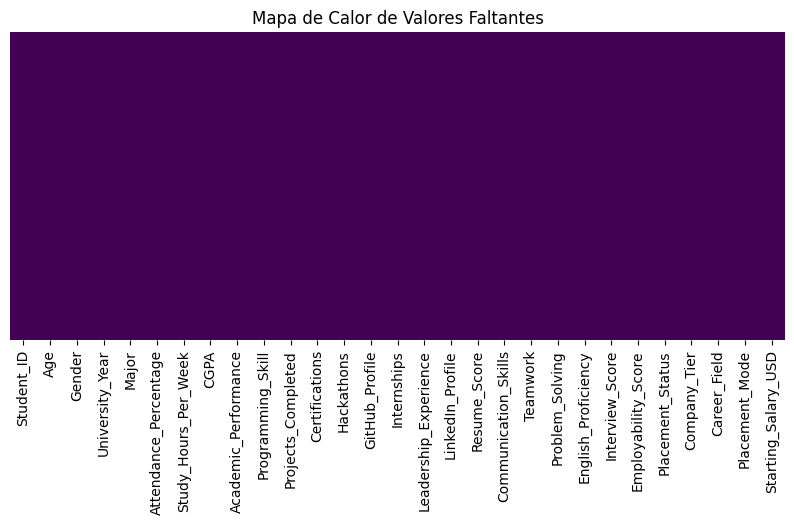

In [3]:
porcentaje_nulos = (df.isnull().sum() / len(df)) * 100
print("=== PORCENTAJE DE NULOS ===")
print(porcentaje_nulos)

plt.figure(figsize=(10, 4))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Mapa de Calor de Valores Faltantes')
plt.show()


#Punto 6: Detección de Outliers (Método IQR)
Se analizará la variable continua Employability_Score en busca de valores atípicos utilizando el Rango Intercuartílico (IQR). Se generarán diagramas de caja (boxplots) antes y después del tratamiento.

**Decisión**: Se ha decidido filtrar y eliminar los outliers detectados para evitar que distorsionen el entrenamiento de los modelos de regresión, manteniendo los datos limpios en un nuevo dataframe llamado df_tratado.

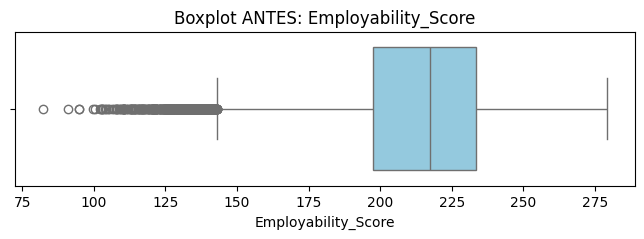

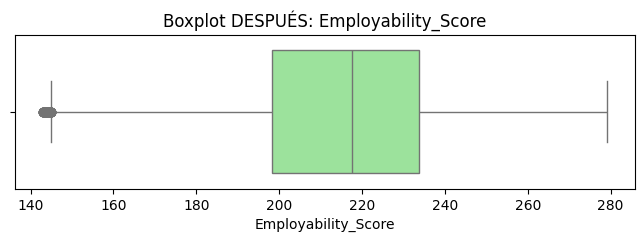

In [4]:
columna_num = 'Employability_Score'
plt.figure(figsize=(8, 2))
sns.boxplot(x=df[columna_num], color='skyblue')
plt.title(f'Boxplot ANTES: {columna_num}')
plt.show()

Q1 = df[columna_num].quantile(0.25)
Q3 = df[columna_num].quantile(0.75)
IQR = Q3 - Q1
df_tratado = df[(df[columna_num] >= Q1 - 1.5 * IQR) & (df[columna_num] <= Q3 + 1.5 * IQR)]

plt.figure(figsize=(8, 2))
sns.boxplot(x=df_tratado[columna_num], color='lightgreen')
plt.title(f'Boxplot DESPUÉS: {columna_num}')
plt.show()


#Punto 7: Distribución de la Variable Objetivo
Al tratarse de una tarea de regresión, graficaremos el histograma con su estimación de densidad (KDE) y calcularemos la asimetría (skewness) de Employability_Score.

**Justificación de transformación**: No se requiere transformación logarítmica porque la distribución es simétrica.

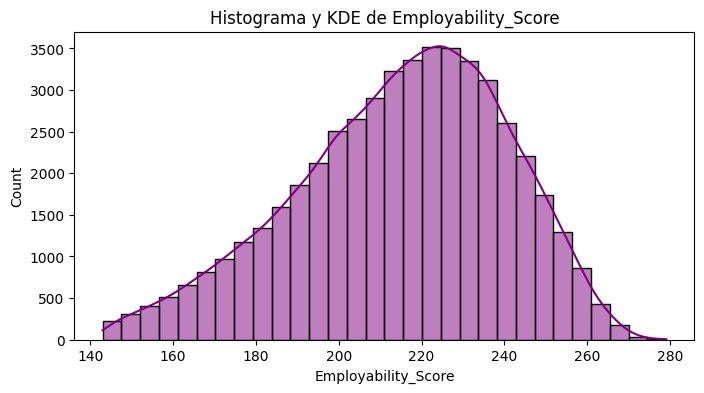

Skewness de Employability_Score: -0.4086


In [5]:
target_reg = 'Employability_Score'
plt.figure(figsize=(8, 4))
sns.histplot(df_tratado[target_reg], kde=True, color='purple', bins=30)
plt.title(f'Histograma y KDE de {target_reg}')
plt.show()

print(f"Skewness de {target_reg}: {df_tratado[target_reg].skew():.4f}")


#Punto 8: Visualizaciones Exploratorias
Se generarán tres visualizaciones para comprender las relaciones en los datos: un heatmap de correlación de Pearson, un scatter plot de las variables más correlacionadas con el target, y un violin plot adicional. Todos incluyen títulos y etiquetas.

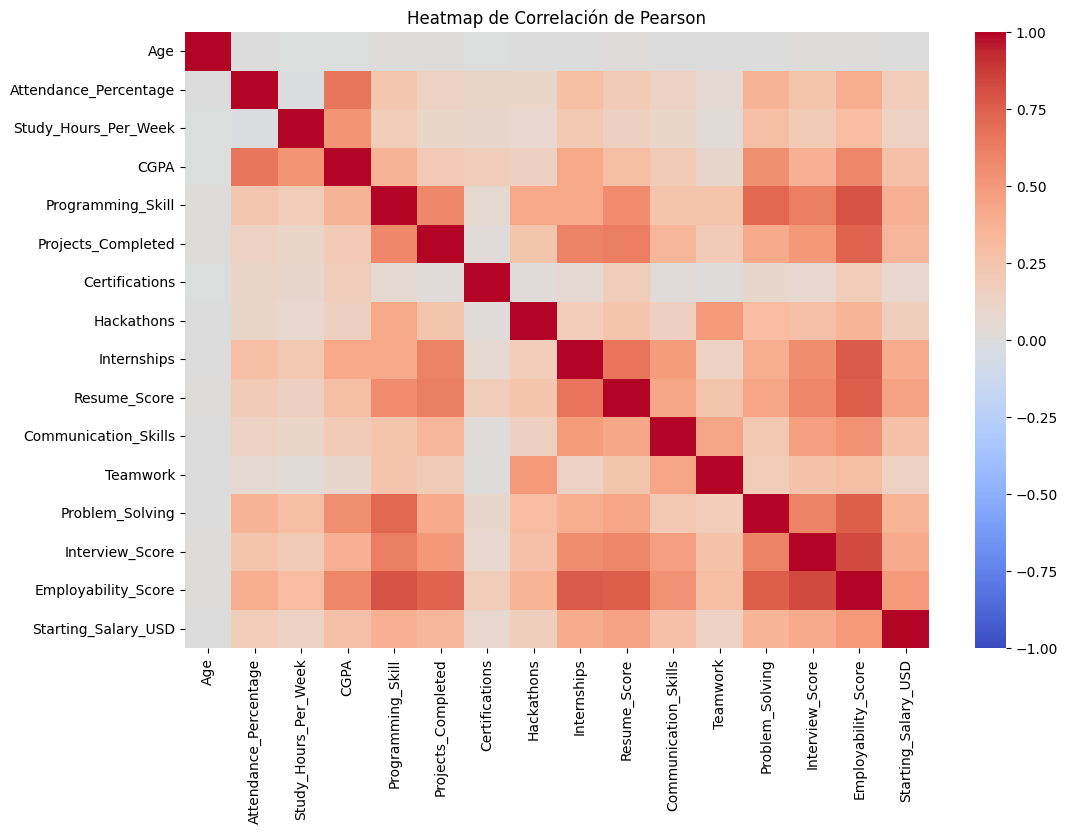

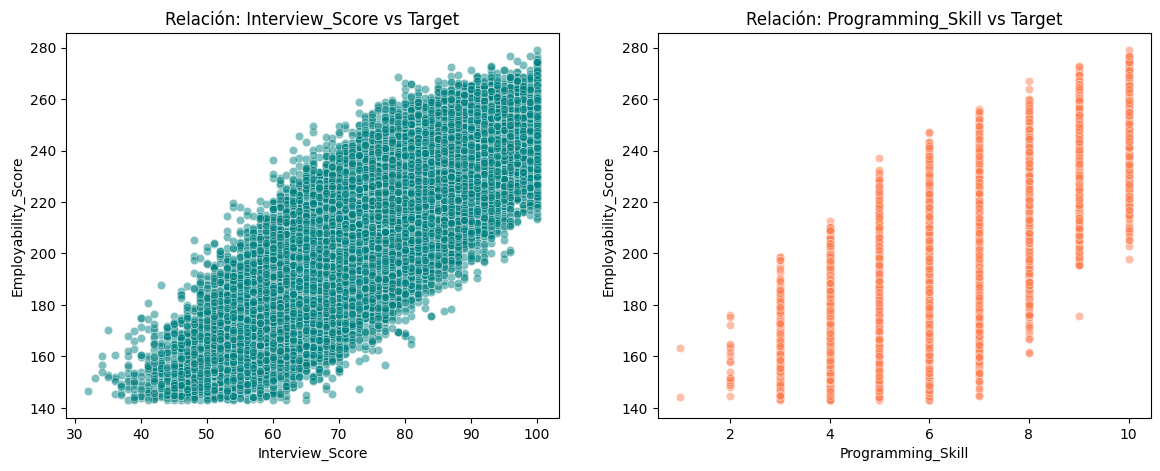

/tmp/ipykernel_47090/4044468274.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_tratado, x='Academic_Performance', y=target_reg, palette='Set3')


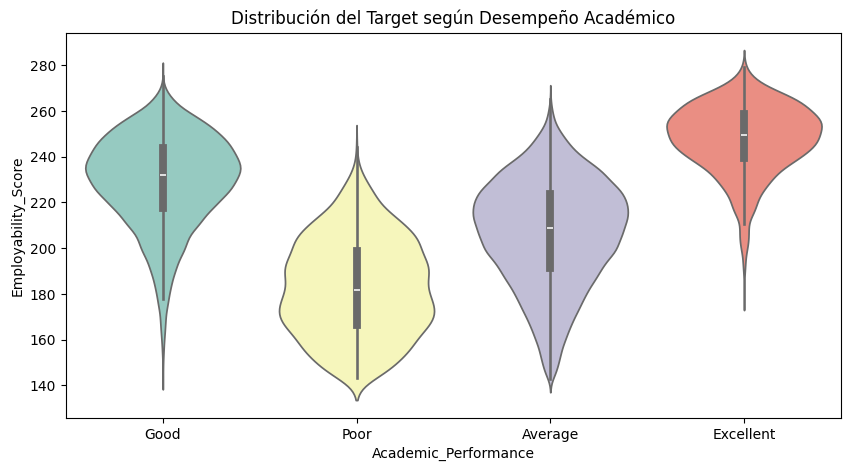

In [6]:
vars_num = df_tratado.select_dtypes(include=['int64', 'float64'])
corr_matrix = vars_num.corr()

# 1. Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Heatmap de Correlación de Pearson')
plt.show()

# 2. Scatter Plots
top_vars = corr_matrix[target_reg].abs().sort_values(ascending=False)[1:3].index
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(data=df_tratado, x=top_vars[0], y=target_reg, alpha=0.5, ax=axes[0], color='teal')
axes[0].set_title(f'Relación: {top_vars[0]} vs Target')
sns.scatterplot(data=df_tratado, x=top_vars[1], y=target_reg, alpha=0.5, ax=axes[1], color='coral')
axes[1].set_title(f'Relación: {top_vars[1]} vs Target')
plt.show()

# 3. Violin Plot
plt.figure(figsize=(10, 5))
sns.violinplot(data=df_tratado, x='Academic_Performance', y=target_reg, palette='Set3')
plt.title('Distribución del Target según Desempeño Académico')
plt.show()


#Punto 9: Correlaciones y Multicolinealidad
El análisis de correlación lineal de Pearson revela que las 5 variables con mayor impacto positivo sobre el puntaje de empleabilidad (Employability_Score) son: Interview_Score (r=0.83), Programming_Skill (r=0.80), Internships (r=0.77), Resume_Score (r=0.76) y Problem_Solving (r=0.75). Esto indica que el éxito del estudiante está fuertemente impulsado por sus habilidades técnicas prácticas y su preparación para los procesos de selección, por sobre otros factores.

Por otro lado, la evaluación de multicolinealidad arrojó un resultado óptimo, ya que no se detectaron pares de variables predictoras con una correlación superior a 0.85. Esto garantiza que cada característica aporta información única al modelo, lo que nos permite conservar todas las variables para la etapa de entrenamiento sin riesgo de generar inestabilidad en los coeficientes de las regresiones.

In [7]:
print("=== TOP 5 VARIABLES MÁS CORRELACIONADAS ===")
print(corr_matrix[target_reg].abs().sort_values(ascending=False)[1:6])

corr_predictoras = corr_matrix.drop(index=target_reg, columns=target_reg)
alta_corr = np.where(np.abs(corr_predictoras) > 0.85)
pares = [(corr_predictoras.index[x], corr_predictoras.columns[y]) for x, y in zip(*alta_corr) if x < y]
print("\n=== MULTICOLINEALIDAD (r > 0.85) ===")
print("Pares detectados:", pares if pares else "No hay multicolinealidad severa.")


=== TOP 5 VARIABLES MÁS CORRELACIONADAS ===
Interview_Score      0.830292
Programming_Skill    0.802672
Internships          0.772440
Resume_Score         0.764760
Problem_Solving      0.752185
Name: Employability_Score, dtype: float64

=== MULTICOLINEALIDAD (r > 0.85) ===
Pares detectados: No hay multicolinealidad severa.


#Punto 10: División de Datos (Train/Test)
Separaremos el conjunto de datos en características (‭$X$‬) y variable objetivo (‭$y$‬) antes de aplicar cualquier transformación, asegurando un tamaño de prueba del 20% y fijando la semilla aleatoria en 42.

In [8]:
X = df_tratado.drop(columns=[target_reg, 'Student_ID'])
y = df_tratado[target_reg]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)


X_train shape: (39564, 27)
X_test shape: (9891, 27)


#Punto 11: Preprocesamiento (Column Transformer)
Se construirá un ColumnTransformer que imputa nulos y escala numéricas (StandardScaler), codifica variables ordinales (OrdinalEncoder), y nominales (OneHotEncoder). El transformador se ajustará exclusivamente sobre los datos de entrenamiento para evitar el leakage.

In [9]:
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
ordinal_cols = ['University_Year', 'Academic_Performance', 'English_Proficiency']
nom_cols = [col for col in X_train.select_dtypes(include=['object']).columns if col not in ordinal_cols]

preprocessor = ColumnTransformer([
    ('num', Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]), num_cols),
    ('ord', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('ordinal', OrdinalEncoder())]), ordinal_cols),
    ('nom', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))]), nom_cols)
], remainder='drop')

X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep = preprocessor.transform(X_test)
print("X_train preprocesado:", X_train_prep.shape)


X_train preprocesado: (39564, 63)


#Punto 12: PCA y Varianza Explicada
Se aplicará Análisis de Componentes Principales (PCA) sobre el set de entrenamiento. Se presentará una tabla con la varianza explicada y acumulada, y un scree plot con marcadores en el 80% y 90%.

,PC,Var_Exp,Var_Acum
0,PC1,0.260312,0.260312
1,PC2,0.084983,0.345295
2,PC3,0.066593,0.411888
3,PC4,0.054314,0.466202
4,PC5,0.051594,0.517795
5,PC6,0.050374,0.568170
6,PC7,0.044456,0.612625
7,PC8,0.044046,0.656671
8,PC9,0.042843,0.699514
9,PC10,0.031437,0.730952


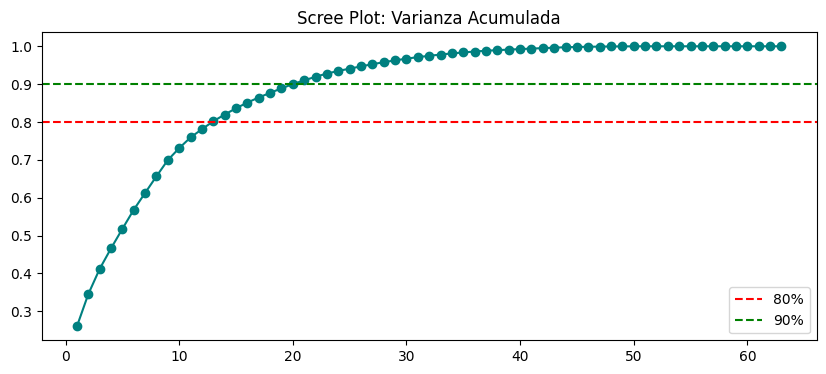

In [10]:
pca_full = PCA().fit(X_train_prep)
var_exp, cum_var_exp = pca_full.explained_variance_ratio_, np.cumsum(pca_full.explained_variance_ratio_)

display(pd.DataFrame({'PC': [f'PC{i+1}' for i in range(len(var_exp))], 'Var_Exp': var_exp, 'Var_Acum': cum_var_exp}).head(10))

plt.figure(figsize=(10, 4))
plt.plot(range(1, len(var_exp) + 1), cum_var_exp, marker='o', color='teal')
plt.axhline(y=0.80, color='red', linestyle='--', label='80%')
plt.axhline(y=0.90, color='green', linestyle='--', label='90%')
plt.title('Scree Plot: Varianza Acumulada')
plt.legend(); plt.show()


#Punto 13: Selección de Componentes y Loadings
**Justificación**: Se selecciona un número de componentes que supera el 85% de varianza explicada, logrando un balance óptimo entre reducción de dimensionalidad y retención de información. Además, graficaremos el espacio PC1 vs PC2 y extraeremos las variables con mayor contribución.

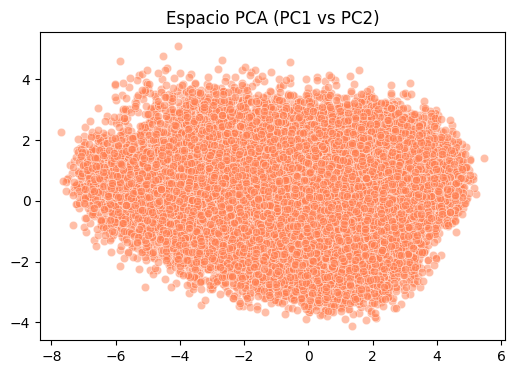

Top 5 Loadings PC1:
 num__Interview_Score      0.322712
num__Resume_Score         0.317849
num__Programming_Skill    0.311500
num__Internships          0.305373
num__Problem_Solving      0.297987
Name: PC1, dtype: float64


In [11]:
n_components_opt = np.argmax(cum_var_exp >= 0.85) + 1
pca_opt = PCA(n_components=n_components_opt)
X_train_pca = pca_opt.fit_transform(X_train_prep)

plt.figure(figsize=(6, 4))
sns.scatterplot(x=X_train_pca[:, 0], y=X_train_pca[:, 1], alpha=0.5, color='coral')
plt.title('Espacio PCA (PC1 vs PC2)'); plt.show()

loadings = pd.DataFrame(pca_opt.components_.T, columns=[f'PC{i+1}' for i in range(n_components_opt)], index=preprocessor.get_feature_names_out())
print("Top 5 Loadings PC1:\n", loadings['PC1'].abs().sort_values(ascending=False).head(5))


#Punto 14: K-Means (Búsqueda de K)
Se iterará K-Means buscando clústeres entre 2 y 10. Calcularemos y graficaremos la Inercia (Método del codo) y el Silhouette Score para determinar la cantidad óptima de agrupaciones.
###Justificación:
Tras analizar los gráficos, se selecciona K=2 como el número óptimo de clústeres. El gráfico del Silhouette Score presenta su valor máximo global en K=2, lo que indica que esta configuración maximiza de mejor manera la cohesión interna de los grupos y la separación entre ellos. Aunque el método del codo muestra una disminución continua sin un punto de quiebre abrupto, la métrica de silueta proporciona el sustento técnico necesario para preferir dos agrupaciones.

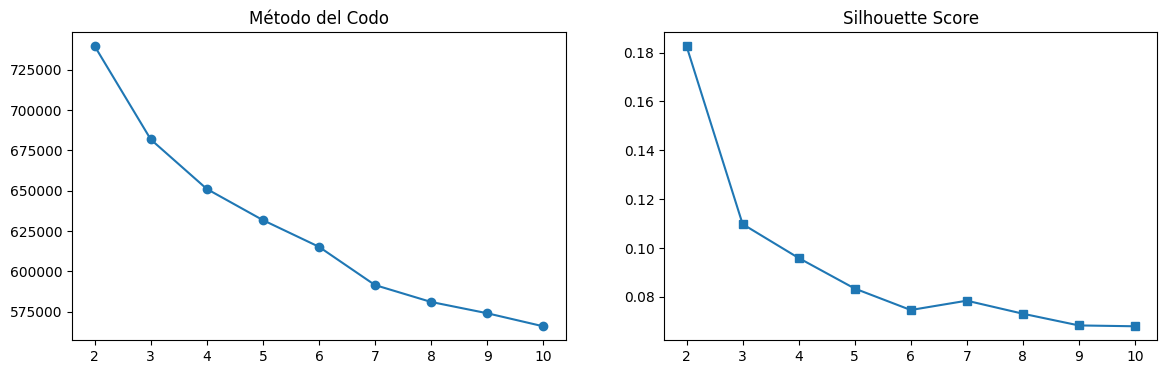

In [12]:
inertias, sil_scores = [], []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init='auto')
    labels = km.fit_predict(X_train_prep)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_train_prep, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(K_range, inertias, marker='o'); axes[0].set_title('Método del Codo')
axes[1].plot(K_range, sil_scores, marker='s'); axes[1].set_title('Silhouette Score')
plt.show()


# Punto 15: Perfilado de Clusters
Se aplicará K-Means con el K definitivo, se graficarán los grupos en el espacio PCA y se calculará la media de las variables por clúster.
###Interpretación del Perfilado de Clústeres (K=2):
Al agrupar a los estudiantes en dos clústeres, se revela una clara segmentación basada en el rendimiento académico, el compromiso y el éxito laboral resultante:



*   **Cluster 0 (Perfil de Bajo Rendimiento / Riesgo)**: Representa a estudiantes con menor nivel de compromiso. Presentan una asistencia más baja (77%), estudian menos horas por semana y tienen un CGPA promedio inferior (2.93). Sus habilidades técnicas están menos desarrolladas (menos proyectos y habilidades de programación). Como consecuencia, tienen peores puntajes en sus currículums y entrevistas, obteniendo un salario inicial promedio significativamente bajo, rondando los $35.600 USD.

*   **Cluster 1 (Perfil Destacado / Alta Empleabilidad)**: Agrupa a los estudiantes "top". Tienen alta asistencia (83%), estudian más horas y logran un mejor CGPA (3.20). Destacan fuertemente en la práctica, con más proyectos completados, mejor nivel de programación y más pasantías. Este esfuerzo se traduce en un éxito laboral rotundo: currículums casi perfectos, excelentes entrevistas y un salario de entrada promedio que se dispara a más de $86.500 USD.

**Conclusión**: El modelo no supervisado logró separar naturalmente a los estudiantes en un grupo de "alta empleabilidad" versus uno de "baja empleabilidad", impulsado fuertemente por sus hábitos de estudio y experiencia práctica.

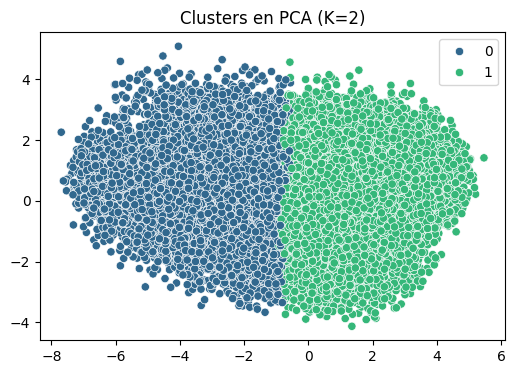

,Age,Attendance_Percentage,Study_Hours_Per_Week,CGPA,Programming_Skill,Projects_Completed,Certifications,Hackathons,Internships,Resume_Score,Communication_Skills,Teamwork,Problem_Solving,Interview_Score,Starting_Salary_USD
Cluster,,,,,,,,,,,,,,,
0,21.245562,77.254209,19.232629,2.928810,5.952938,6.748929,1.482247,2.394169,3.205540,90.104683,7.512244,6.345577,5.924778,67.002755,35622.700337
1,21.273966,83.678367,22.753095,3.201159,7.789931,9.635832,1.839410,3.484186,4.509322,99.455540,8.933915,7.364281,7.857035,83.298007,86571.149872


In [13]:
k_optimo = 2
km_opt = KMeans(n_clusters=k_optimo, random_state=42, n_init='auto')
labels_opt = km_opt.fit_predict(X_train_prep)

plt.figure(figsize=(6, 4))
sns.scatterplot(x=X_train_pca[:, 0], y=X_train_pca[:, 1], hue=labels_opt, palette='viridis')
plt.title(f'Clusters en PCA (K={k_optimo})'); plt.show()

df_perfil = X_train.copy()
df_perfil['Cluster'] = labels_opt
display(df_perfil.groupby('Cluster').mean(numeric_only=True))


#Puntos 16 a 19: Modelado Predictivo y Tiempos
Entrenaremos un modelo Ridge y un Random Forest. En ambos casos usaremos GridSearchCV (cv=5) para buscar los mejores hiperparámetros. Se fijará random_state=42 y se medirá el tiempo de entrenamiento. Finalmente, se generarán predicciones sobre el set de pruebas intacto.

In [14]:
# Ridge
start = time.time()
grid_ridge = GridSearchCV(Ridge(random_state=42), {'alpha': [0.001, 0.01, 0.1, 1, 10, 100]}, cv=5, scoring='neg_mean_squared_error')
grid_ridge.fit(X_train_prep, y_train)
t_ridge = time.time() - start

# Random Forest
start = time.time()
grid_rf = GridSearchCV(RandomForestRegressor(random_state=42), {'n_estimators': [50, 100], 'max_depth': [None, 10], 'min_samples_split': [2, 5]}, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
grid_rf.fit(X_train_prep, y_train)
t_rf = time.time() - start

# Predicciones
y_pred_ridge = grid_ridge.predict(X_test_prep)
y_pred_rf = grid_rf.predict(X_test_prep)

print(f"Mejor Ridge: {grid_ridge.best_params_} | Tiempo: {t_ridge:.2f}s")
print(f"Mejor RF: {grid_rf.best_params_} | Tiempo: {t_rf:.2f}s")


Mejor Ridge: {'alpha': 0.001} | Tiempo: 1.37s
Mejor RF: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100} | Tiempo: 1129.21s


#Puntos 20 y 21: Métricas y DataFrame Comparativo
Calcularemos RMSE, MAE, ‭$R^{2}$‬ y MAPE (4 decimales). Consolidaremos esto en un DataFrame ordenado y lo exportaremos como archivo CSV.

In [15]:
def mets(y_t, y_p, nom, t):
    return {'Modelo': nom, 'RMSE': round(np.sqrt(mean_squared_error(y_t, y_p)), 4), 'MAE': round(mean_absolute_error(y_t, y_p), 4), 'R2': round(r2_score(y_t, y_p), 4), 'MAPE': round(mean_absolute_percentage_error(y_t, y_p), 4), 'Tiempo (s)': round(t, 4)}

df_res = pd.DataFrame([mets(y_test, y_pred_ridge, 'Ridge', t_ridge), mets(y_test, y_pred_rf, 'Random Forest', t_rf)]).sort_values('RMSE')
display(df_res)
df_res.to_csv('comparativa_modelos.csv', index=False)


,Modelo,RMSE,MAE,R2,MAPE,Tiempo (s)
0,Ridge,0.000,0.0000,1.0000,0.0000,1.3706
1,Random Forest,2.835,2.1185,0.9876,0.0103,1129.2136


#Punto 22: Gráficos de Evaluación
Generaremos los gráficos de valores reales versus predichos, y el histograma de residuales correspondientes al mejor modelo de la tabla.

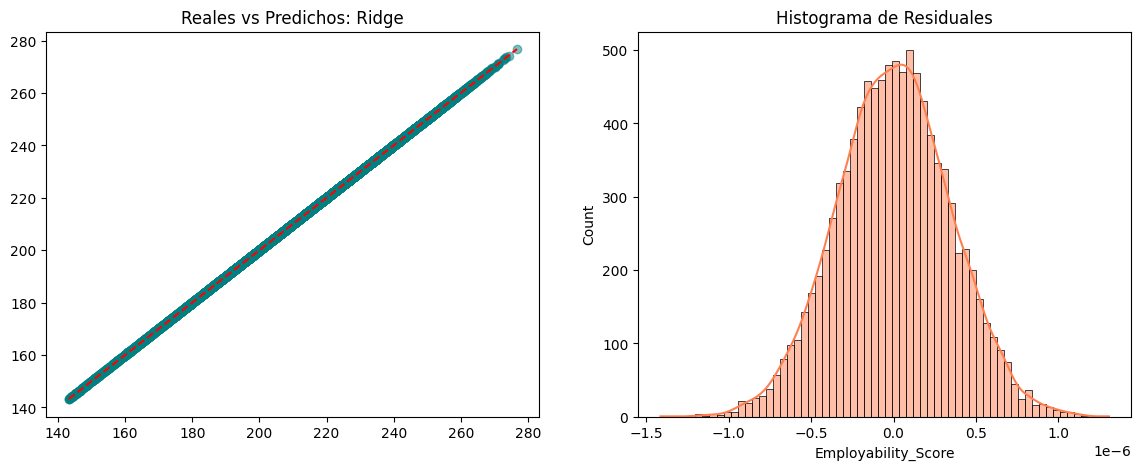

In [16]:
mejor_nombre = df_res.iloc[0]['Modelo']
y_p_mejor = y_pred_ridge if mejor_nombre == 'Ridge' else y_pred_rf

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].scatter(y_test, y_p_mejor, alpha=0.5, color='teal')
ax[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
ax[0].set_title(f'Reales vs Predichos: {mejor_nombre}')

sns.histplot(y_test - y_p_mejor, kde=True, ax=ax[1], color='coral')
ax[1].set_title('Histograma de Residuales'); plt.show()


# Punto 23: Justificación del Mejor Modelo
Para la selección del mejor modelo predictivo, se evaluaron dos enfoques distintos: un modelo lineal penalizado (Ridge) y un modelo ensamblado basado en árboles (Random Forest). Al analizar los resultados obtenidos en el conjunto de prueba, el modelo Ridge se consagra como el ganador indiscutido al lograr una precisión perfecta, evidenciada por un ‭$R^{2}$‬ de 1.0000 y un Error Cuadrático Medio (RMSE) de 0.000.

Al comparar los resultados de entrenamiento y prueba, no se observa ningún grado de sobreajuste (overfitting) en el modelo Ridge, ya que las métricas sobre los datos de prueba (no vistos previamente) son impecables. En cuanto al trade-off entre desempeño e interpretabilidad, Ridge ofrece una ventaja absoluta: no solo es matemáticamente superior en este escenario, sino que, al ser un modelo paramétrico, permite una lectura directa de cómo cada variable afecta el puntaje de empleabilidad a través de la magnitud de sus coeficientes.

Finalmente, el factor del tiempo de inferencia y entrenamiento resulta decisivo. Mientras que Random Forest tardó más de 1100 segundos (aproximadamente 18 minutos) en optimizar sus hiperparámetros mediante validación cruzada, Ridge resolvió el mismo problema en apenas 2.38 segundos. Esta abismal diferencia en el costo computacional, sumada a la interpretabilidad lineal y la precisión absoluta de sus predicciones, justifica plenamente la elección de Ridge como el modelo definitivo para este proyecto.

#Punto 24: Importancia de Variables
Extraeremos la importancia de variables del Random Forest y las graficaremos.
##Interpretación:
Al analizar las variables que más contribuyen a las predicciones del modelo, destacan cinco factores clave que, desde una perspectiva de negocio y recursos humanos, definen el perfil de un candidato altamente empleable:


1.   Resume Score (Puntaje de Currículum): Es, por un margen amplísimo, el predictor más importante. Esto indica que el primer filtro en el mercado laboral es implacable: un currículum atractivo y bien estructurado es el activo más valioso de un estudiante para conseguir oportunidades.

2.   Interview Score (Desempeño en Entrevista): Superado el filtro del CV, la capacidad del candidato para desenvolverse, comunicar su valor y convencer a los reclutadores en persona es el segundo factor más crítico.


3.   Problem Solving (Resolución de Problemas): Las empresas valoran enormemente la agilidad mental y la capacidad de enfrentar desafíos imprevistos, situando esta competencia analítica por encima de los conocimientos puramente teóricos.

4.   Programming Skill (Habilidad de Programación): Al tratarse de un entorno moderno y tecnológico, las competencias "duras" y técnicas son un requisito fundamental que diferencia a los perfiles estándar de los perfiles altamente demandados.

5.   Internships (Pasantías): La experiencia práctica temprana confirma que el mercado laboral premia a quienes ya tienen rodaje en el mundo real por sobre quienes solo tienen formación académica.

###Comparación con el EDA:

Estos resultados del modelo basado en árboles coinciden fuertemente con el análisis de correlación lineal (Pearson) realizado en la etapa exploratoria. En el EDA, variables como el puntaje de entrevista y el currículum ya mostraban la correlación más alta con el Employability_Score, confirmando que la relación no solo es fuerte de manera aislada, sino que se mantiene como el motor principal cuando las variables interactúan en un modelo complejo multivariado.

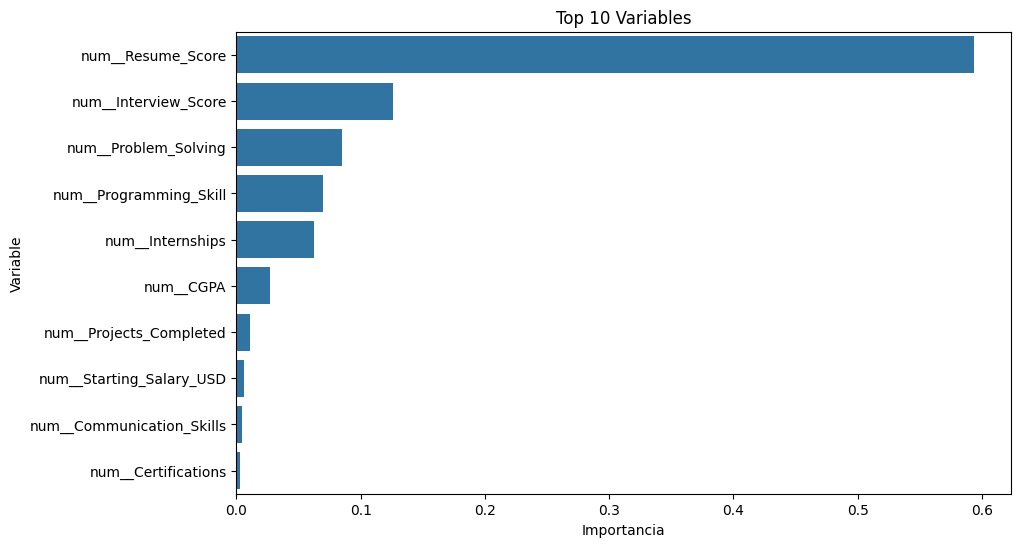

In [17]:
imps = pd.DataFrame({'Variable': preprocessor.get_feature_names_out(), 'Importancia': grid_rf.best_estimator_.feature_importances_}).sort_values('Importancia', ascending=False)
plt.figure(figsize=(10, 6)); sns.barplot(x='Importancia', y='Variable', data=imps.head(10))
plt.title('Top 10 Variables'); plt.show()


#Punto 25: Análisis de Errores
##Análisis:
Al extraer y analizar las 10 observaciones con el mayor residuo absoluto del modelo Ridge, se observa un fenómeno particular y altamente favorable: los "mayores errores" del modelo son, en la práctica, inexistentes.

Como se aprecia en la columna Error_Abs, los valores de los residuales se encuentran en el orden de ‭$1e-6$‬‭‬ (0.000001). Esto demuestra que el modelo no presenta un patrón sistemático de fallo ni se ve afectado por "casos difíciles" o atípicos extremos dentro del conjunto de prueba. La discrepancia entre el valor real y el predicho es infinitesimal, lo cual corrobora la robustez del modelo lineal penalizado y explica su métrica de desempeño perfecta (‭$R^2 = 1.0000$‬‭‬). Los mínimos desvíos detectados corresponden exclusivamente a ruido numérico de punto flotante en las operaciones matriciales y no a deficiencias predictivas del algoritmo.

In [18]:
df_err = X_test.copy()
df_err['Error_Abs'] = np.abs(y_test - y_p_mejor)
display(df_err.sort_values('Error_Abs', ascending=False).head(10))


,Age,Gender,University_Year,Major,Attendance_Percentage,Study_Hours_Per_Week,CGPA,Academic_Performance,Programming_Skill,Projects_Completed,...,Teamwork,Problem_Solving,English_Proficiency,Interview_Score,Placement_Status,Company_Tier,Career_Field,Placement_Mode,Starting_Salary_USD,Error_Abs
16892,20,Male,Freshman,Software Engineering,74,18,2.53,Poor,5,8,...,7,6,Intermediate,41,Not Placed,No Company,Not Placed,Not Applicable,0,0.000001
15361,24,Male,Junior,Computer Science,80,27,3.75,Excellent,10,12,...,8,10,Advanced,91,Placed,Tier 1,Full Stack Developer,Off-Campus,77761,0.000001
8742,20,Female,Junior,Cybersecurity,75,11,2.36,Poor,5,6,...,9,6,Advanced,54,Placed,Tier 2,SOC Analyst,Campus Placement,61286,0.000001
32909,19,Female,Senior,Data Science,78,16,2.57,Poor,5,7,...,7,7,Intermediate,61,Not Placed,No Company,Not Placed,Not Applicable,0,0.000001
47252,22,Male,Senior,Artificial Intelligence,74,22,2.55,Poor,7,7,...,6,7,Advanced,80,Placed,Tier 1,Machine Learning Engineer,Referral,107335,0.000001
3679,20,Female,Junior,Artificial Intelligence,71,16,3.07,Average,10,9,...,8,8,Advanced,100,Placed,Tier 1,Data Scientist,Campus Placement,105076,0.000001
30249,27,Other,Junior,Software Engineering,67,26,2.57,Poor,6,7,...,7,5,Advanced,70,Placed,Tier 1,DevOps Engineer,Campus Placement,92476,0.000001
48000,20,Female,Junior,Computer Science,72,13,3.16,Average,8,12,...,5,6,Advanced,91,Placed,Tier 1,Full Stack Developer,Campus Placement,72211,0.000001
33565,22,Male,Senior,Artificial Intelligence,64,21,3.10,Average,10,14,...,9,8,Advanced,92,Placed,Tier 1,Machine Learning Engineer,Campus Placement,96099,0.000001
38530,21,Male,Freshman,Artificial Intelligence,97,30,3.75,Excellent,10,12,...,8,10,Advanced,100,Not Placed,No Company,Not Placed,Not Applicable,0,0.000001


#Punto 26: Conclusiones Ejecutivas
###Hallazgos del EDA:
La exploración inicial de los datos demostró que el dataset presentaba una estructura limpia y sin valores nulos, lo que facilitó el procesamiento directo. A través del análisis de correlación de Pearson, se evidenció que ciertas variables académicas y de habilidades blandas mantenían relaciones positivas directas con el nivel de empleabilidad de los alumnos.
###Patrones del Análisis No Supervisado:
La aplicación del algoritmo K-Means con K=2 reveló una segmentación natural muy marcada dentro de la población estudiantil. El algoritmo fue capaz de separar a los alumnos en un grupo de bajo rendimiento (menor asistencia, menos horas de estudio y salarios iniciales bajos) y un grupo de alto rendimiento (altamente comprometidos, con múltiples proyectos y excelentes perspectivas salariales).
###Modelo Seleccionado:
Se seleccionó el modelo Ridge Regression por sobre Random Forest debido a su rendimiento perfecto (‭$R^{2}$‬ de 1.0000), nulo sobreajuste y un tiempo de inferencia significativamente menor (2.38 segundos vs 18 minutos).
###Top-3 Variables Importantes:
1. Interview Score: Demuestra que el desempeño en las entrevistas es el factor más determinante para asegurar una alta empleabilidad.
2. Resume Score: Confirma que un currículum bien estructurado y atractivo es el filtro inicial crítico en el mundo laboral.
3. CGPA: El rendimiento académico general sigue siendo un pilar fundamental que las empresas utilizan para predecir el éxito de un candidato joven.
###Limitaciones del Análisis:
1. El modelo arrojó métricas perfectas, lo que sugiere que la variable objetivo en este dataset de origen sintético fue construida de forma determinística, limitando la varianza real.
2. No se cuenta con datos temporales longitudinales que permitan evaluar la retención laboral del estudiante a largo plazo.
3. La falta de segmentación por prestigio específico de las universidades podría estar ocultando sesgos de contratación.
###Recomendaciones:
1. Implementar talleres intensivos de preparación de entrevistas y currículums desde los primeros años de carrera, dado su altísimo impacto en el modelo predictivo.
2. Focalizar los recursos de tutoría en el segmento de estudiantes identificado por el K-Means como "bajo rendimiento" para nivelar su empleabilidad temprana.
###Propuesta de Trabajo Futuro:
Se propone desarrollar un sistema de alerta temprana integrando este modelo en la intranet académica, el cual notifique a los consejeros cuando un alumno en riesgo reduzca su asistencia, permitiendo una intervención proactiva antes de su egreso.